In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100.0%
100.0%
100.0%
100.0%


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        return reconstructed

model = Autoencoder().to(device)

In [5]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [6]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, _ in train_loader:
        images = images.view(images.size(0), -1).to(device)

        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

Epoch [1/10], Loss: 0.0450
Epoch [2/10], Loss: 0.0222
Epoch [3/10], Loss: 0.0197
Epoch [4/10], Loss: 0.0184
Epoch [5/10], Loss: 0.0174
Epoch [6/10], Loss: 0.0165
Epoch [7/10], Loss: 0.0159
Epoch [8/10], Loss: 0.0154
Epoch [9/10], Loss: 0.0150
Epoch [10/10], Loss: 0.0146


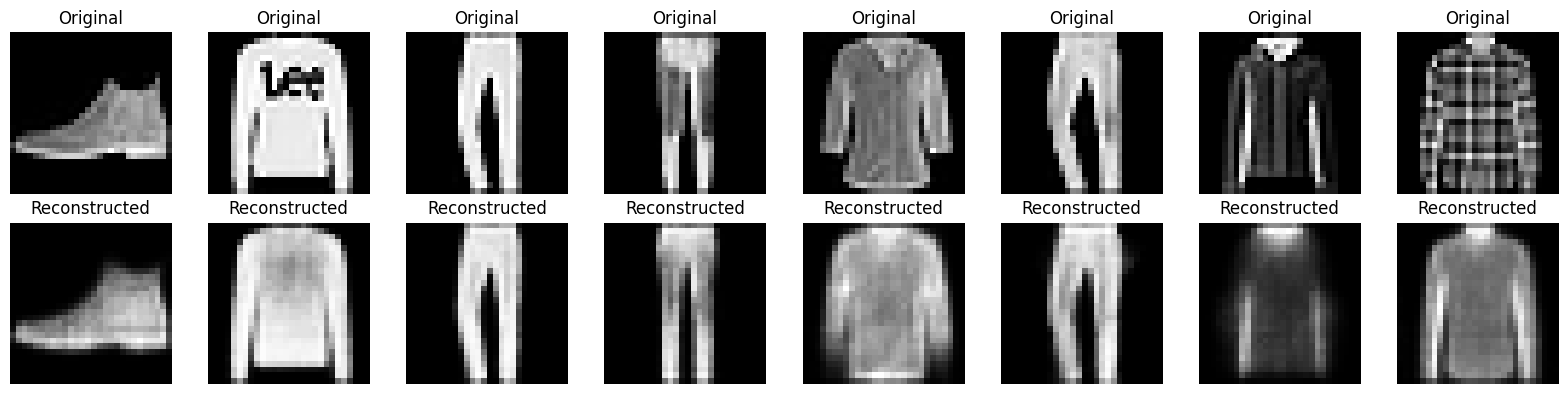

In [7]:
model.eval()
with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.view(images.size(0), -1).to(device)

    reconstructed = model(images)

images = images.cpu().view(-1, 1, 28, 28)
reconstructed = reconstructed.cpu().view(-1, 1, 28, 28)

n = 8
plt.figure(figsize=(16, 4))

for i in range(n):
    # original
    plt.subplot(2, n, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # reconstructed
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].squeeze(), cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()